# **Import**

In [1]:
import warnings

warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# **Data Load**

In [4]:
cd /content/drive/MyDrive/[Projects]/Dacon/운수종사자 인지적 특성 데이터를 활용한 교통사고 위험 예측 AI 경진대회/Data

/content/drive/MyDrive/[Projects]/Dacon/운수종사자 인지적 특성 데이터를 활용한 교통사고 위험 예측 AI 경진대회/Data


In [5]:
train_b = pd.read_csv('train_b_derived.csv')
train_b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297513 entries, 0 to 297512
Data columns (total 36 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Label                    297513 non-null  int64  
 1   Age                      297513 non-null  int64  
 2   B1_task1_accuracy        297513 non-null  float64
 3   B1_task2_change_acc      297513 non-null  float64
 4   B1_task2_non_change_acc  297513 non-null  float64
 5   B1_task2_accuracy_gap    297513 non-null  float64
 6   B1_task2_mean_rt         297513 non-null  float64
 7   B2_task1_accuracy        297513 non-null  float64
 8   B2_task2_change_acc      297513 non-null  float64
 9   B2_task2_non_change_acc  297513 non-null  float64
 10  B2_task2_accuracy_gap    297513 non-null  float64
 11  B2_task2_mean_rt         297513 non-null  float64
 12  B3_accuracy              297513 non-null  float64
 13  B3_mean_rt               297513 non-null  float64
 14  B4_c

# **Clustering**

In [12]:
results = []
y = train_b['Label']

def compute_clusters_silhouette(df, feature, target, sample_size=10000, random_state=42):
    """
    feature별 클러스터링 + silhouette 계산
    Returns: labels, silhouette_score, x_scaled, x_sample
    """
    # feature 데이터
    x_col = df[[feature]].dropna()
    idx = x_col.index
    y_col = target.loc[idx]

    # 샘플링: Stratified
    if len(x_col) > sample_size:
        x_sample, _, y_sample, _ = train_test_split(
            x_col, y_col,
            train_size=sample_size,
            stratify=y_col,
            random_state=random_state
        )
    else:
        x_sample = x_col
        y_sample = y_col

    # 정규화
    x_scaled = StandardScaler().fit_transform(x_sample)

    # KMeans(k=2)
    kmeans = KMeans(n_clusters=2, n_init=5, max_iter=200, random_state=random_state)
    labels = kmeans.fit_predict(x_scaled)

    # Silhouette 계산 (cluster가 1개면 NaN 처리)
    if len(np.unique(labels)) < 2:
        sil_score = np.nan
        print(f"Feature: {feature}, cluster가 1개라 silhouette 계산 불가")
    else:
        sil_score = silhouette_score(x_scaled, labels)
        print(f"Feature: {feature}, Silhouette Score: {sil_score:.4f}")

    return labels, sil_score, x_scaled, x_sample

def plot_cluster_target_mean(labels, x_sample, target, feature_name):
    """
    Cluster별 target 평균 계산 + bar plot 시각화
    Args:
        labels: KMeans 클러스터 레이블 (1차원 array)
        x_sample: 클러스터링에 사용한 feature 샘플 (DataFrame)
        target: target Series (0/1)
        feature_name: feature 이름 (str)
    """
    # target과 합치기
    tmp = pd.DataFrame({
        feature_name: x_sample.values.flatten(),
        'Cluster': labels,
        'Target': target.loc[x_sample.index].values
    })

    # 클러스터별 target 평균 계산
    cluster_mean = tmp.groupby('Cluster')['Target'].mean()
    diff = cluster_mean.max() - cluster_mean.min()

    # 위험 확률이 높은 cluster가 항상 오른쪽으로 오도록 정렬
    cluster_mean = cluster_mean.sort_values(ascending=True)

    print("Cluster별 Target 평균:")
    print(cluster_mean)
    print(f"Target 평균 차이 (Cluster Max - Min): {diff:.4f}")

    # bar plot
    plt.figure(figsize=(6, 4))
    sns.barplot(x=cluster_mean.index, y=cluster_mean.values, palette='tab10')
    plt.title(f"{feature_name} - Mean Target by Cluster (diff={diff:.3f})")
    plt.xlabel("Cluster")
    plt.ylabel("Mean Target (Risk Probability)")
    plt.show()

    return diff

## **Age**

Feature: Age, Silhouette Score: 0.9879
Cluster별 Target 평균:
Cluster
1    0.040284
0    0.044750
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0045


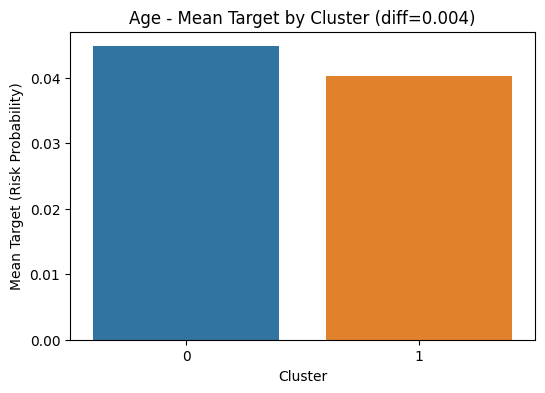

In [13]:
col = 'Age'

labels, sil_score, x_scaled, x_sample = compute_clusters_silhouette(
    train_b, col, y
    )

diff = plot_cluster_target_mean(labels, x_sample, y, col)

results.append({
    'Feature': col,
    'Silhouette': sil_score,
    'Cluster Diff': diff
})

## **B1**

Feature: B1_task1_accuracy, Silhouette Score: 0.7940
Cluster별 Target 평균:
Cluster
0    0.041120
1    0.056194
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0151


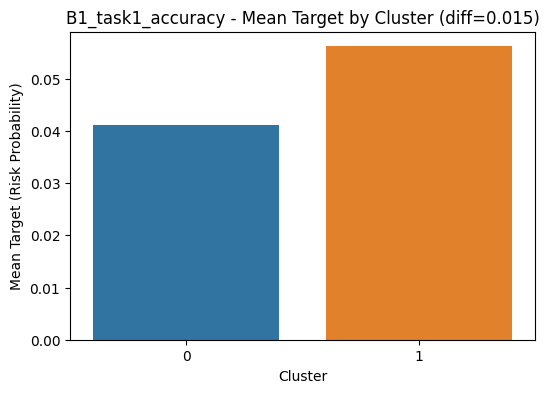

Feature: B1_task2_change_acc, Silhouette Score: 0.7907
Cluster별 Target 평균:
Cluster
1    0.041206
0    0.043023
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0018


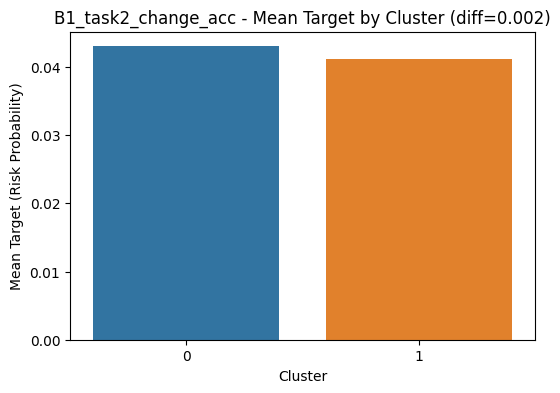

Feature: B1_task2_non_change_acc, Silhouette Score: 0.8208
Cluster별 Target 평균:
Cluster
1    0.041235
0    0.043055
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0018


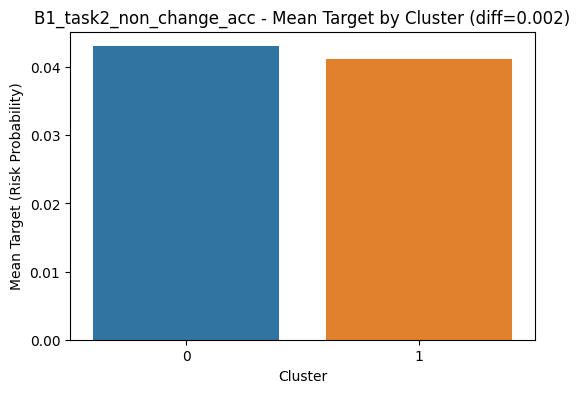

Feature: B1_task2_accuracy_gap, Silhouette Score: 0.7635
Cluster별 Target 평균:
Cluster
1    0.039301
0    0.043869
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0046


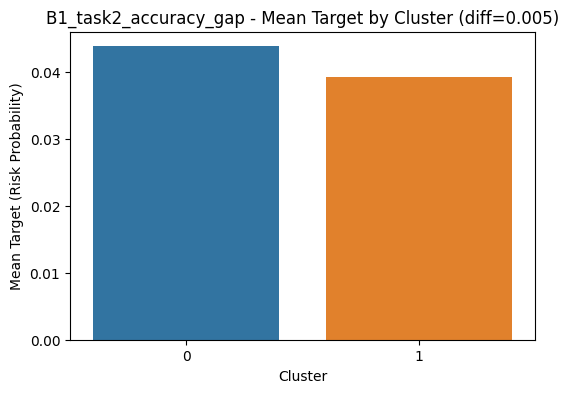

Feature: B1_task2_mean_rt, Silhouette Score: 0.6707
Cluster별 Target 평균:
Cluster
0    0.042086
1    0.042460
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0004


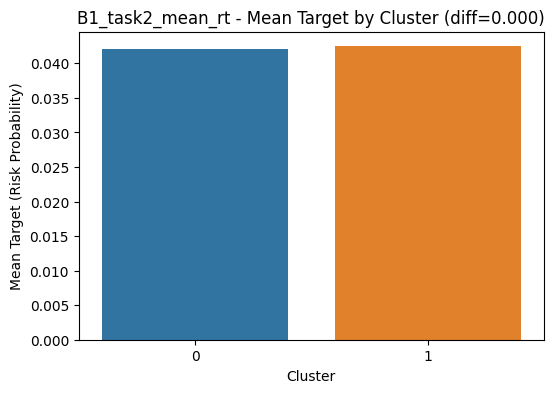

In [14]:
feature_list = ['B1_task1_accuracy', 'B1_task2_change_acc',
                'B1_task2_non_change_acc', 'B1_task2_accuracy_gap',
                'B1_task2_mean_rt']
results_b1 = []

for col in feature_list:
    labels, sil_score, x_scaled, x_sample = compute_clusters_silhouette(train_b, col, y)
    diff = plot_cluster_target_mean(labels, x_sample, y, col)

    results_b1.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

    results.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

In [15]:
results_b1_df = pd.DataFrame(results_b1).sort_values('Cluster Diff', ascending=False)
results_b1_df

,Feature,Silhouette,Cluster Diff
0,B1_task1_accuracy,0.794007,0.015074
3,B1_task2_accuracy_gap,0.763505,0.004568
2,B1_task2_non_change_acc,0.820830,0.001820
1,B1_task2_change_acc,0.790708,0.001817
4,B1_task2_mean_rt,0.670657,0.000375


## **B2**

Feature: B2_task1_accuracy, Silhouette Score: 0.6783
Cluster별 Target 평균:
Cluster
1    0.042199
0    0.042331
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0001


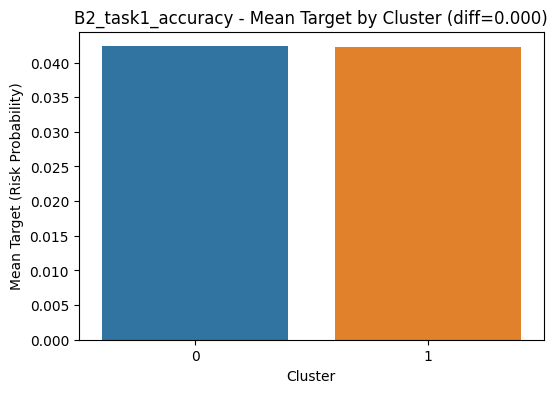

Feature: B2_task2_change_acc, Silhouette Score: 0.7603
Cluster별 Target 평균:
Cluster
1    0.040242
0    0.043852
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0036


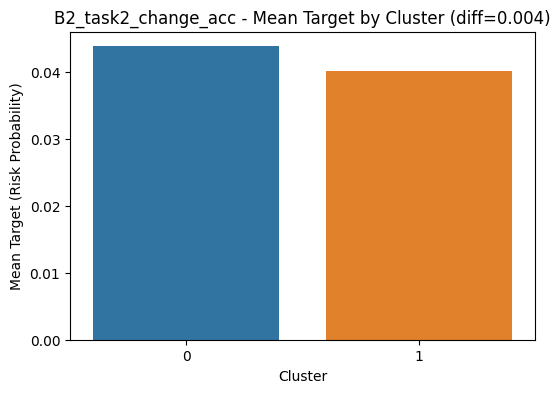

Feature: B2_task2_non_change_acc, Silhouette Score: 0.8091
Cluster별 Target 평균:
Cluster
1    0.038796
0    0.045150
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0064


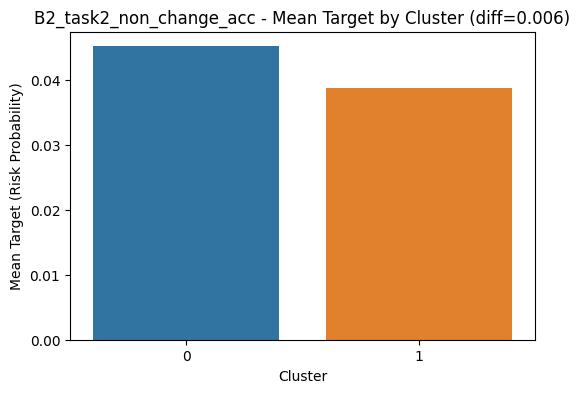

Feature: B2_task2_accuracy_gap, Silhouette Score: 0.7772
Cluster별 Target 평균:
Cluster
0    0.041591
1    0.044698
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0031


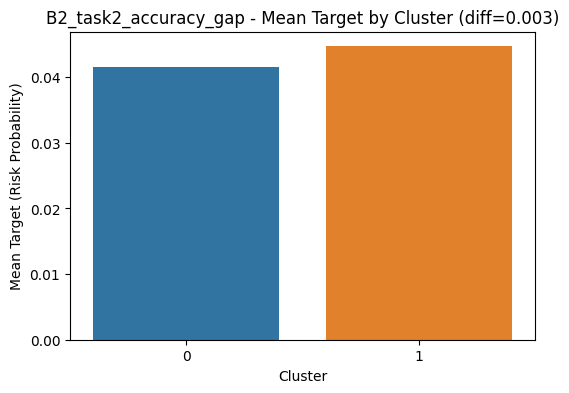

Feature: B2_task2_mean_rt, Silhouette Score: 0.7410
Cluster별 Target 평균:
Cluster
0    0.041339
1    0.042958
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0016


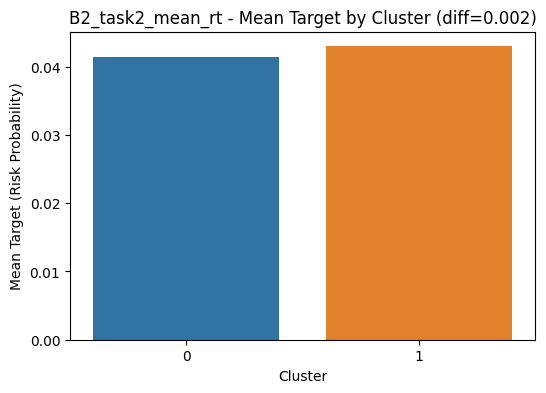

In [16]:
feature_list = ['B2_task1_accuracy', 'B2_task2_change_acc',
                'B2_task2_non_change_acc', 'B2_task2_accuracy_gap',
                'B2_task2_mean_rt']
results_b2 = []

for col in feature_list:
    labels, sil_score, x_scaled, x_sample = compute_clusters_silhouette(train_b, col, y)
    diff = plot_cluster_target_mean(labels, x_sample, y, col)

    results_b2.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

    results.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

In [17]:
results_b2_df = pd.DataFrame(results_b2).sort_values('Cluster Diff', ascending=False)
results_b2_df

,Feature,Silhouette,Cluster Diff
2,B2_task2_non_change_acc,0.809054,0.006354
1,B2_task2_change_acc,0.760273,0.003610
3,B2_task2_accuracy_gap,0.777247,0.003107
4,B2_task2_mean_rt,0.740987,0.001620
0,B2_task1_accuracy,0.678260,0.000131


## **B3**

Feature: B3_accuracy, Silhouette Score: 0.9766
Cluster별 Target 평균:
Cluster
1    0.035897
0    0.042427
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0065


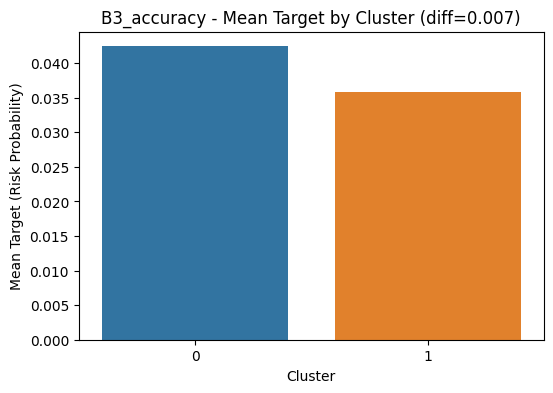

Feature: B3_mean_rt, Silhouette Score: 0.5680
Cluster별 Target 평균:
Cluster
1    0.039975
0    0.043383
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0034


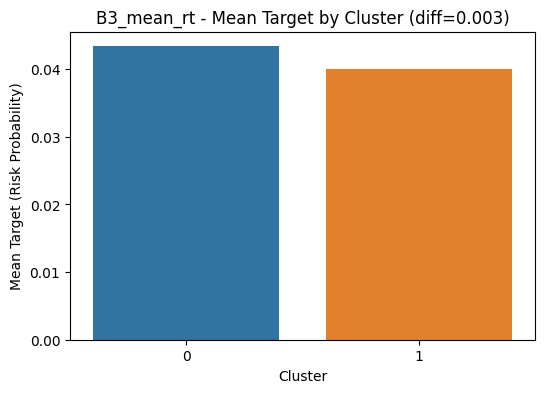

In [18]:
feature_list = ['B3_accuracy', 'B3_mean_rt']
results_b3 = []

for col in feature_list:
    labels, sil_score, x_scaled, x_sample = compute_clusters_silhouette(train_b, col, y)
    diff = plot_cluster_target_mean(labels, x_sample, y, col)

    results_b3.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

    results.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

In [19]:
results_b3_df = pd.DataFrame(results_b3).sort_values('Cluster Diff', ascending=False)
results_b3_df

,Feature,Silhouette,Cluster Diff
0,B3_accuracy,0.976581,0.006530
1,B3_mean_rt,0.567968,0.003408


## **B4**

Feature: B4_congruent_accuracy, Silhouette Score: 0.5715
Cluster별 Target 평균:
Cluster
0    0.041703
1    0.043588
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0019


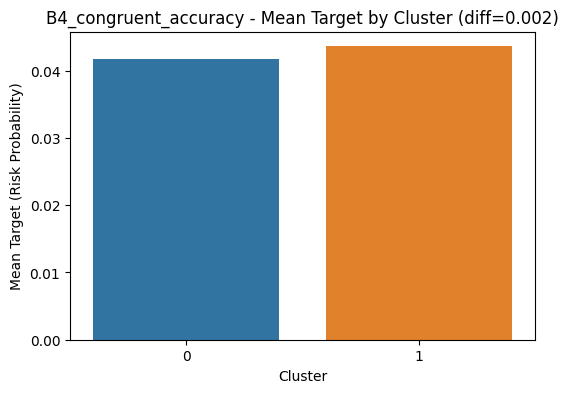

Feature: B4_incongruent_accuracy, Silhouette Score: 0.7887
Cluster별 Target 평균:
Cluster
1    0.039261
0    0.042438
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0032


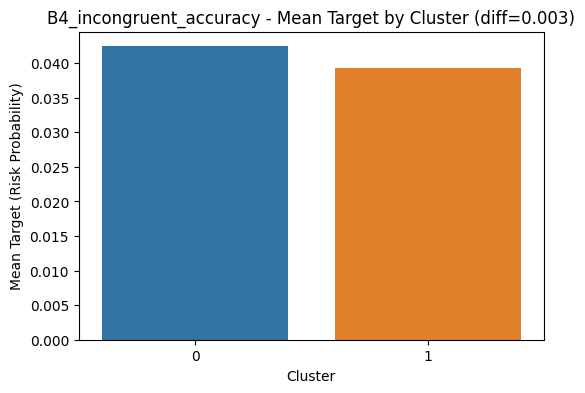

Feature: B4_accuracy_gap, Silhouette Score: 0.5649
Cluster별 Target 평균:
Cluster
0    0.041963
1    0.042759
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0008


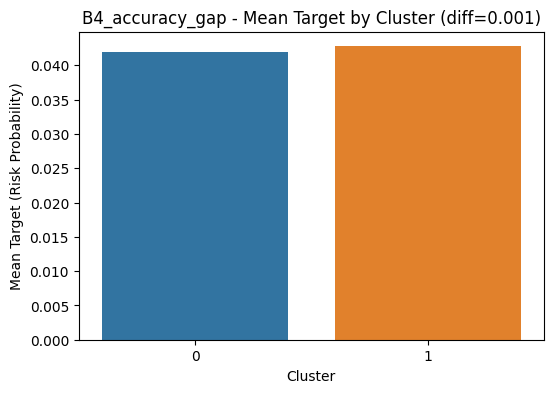

Feature: B4_mean_rt_congruent, Silhouette Score: 0.9805
Cluster별 Target 평균:
Cluster
1    0.000000
0    0.042376
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0424


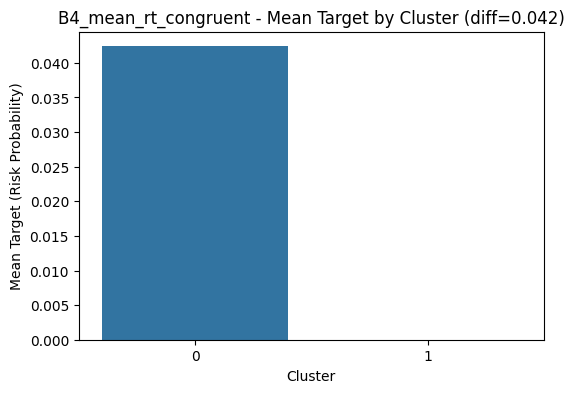

Feature: B4_mean_rt_incongruent, Silhouette Score: 0.9811
Cluster별 Target 평균:
Cluster
1    0.038168
0    0.042355
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0042


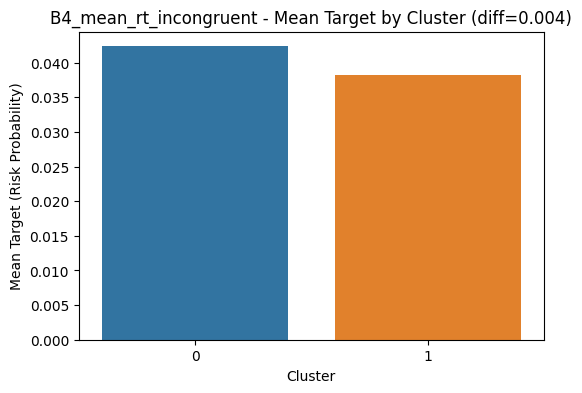

Feature: B4_rt_gap, Silhouette Score: 0.9686
Cluster별 Target 평균:
Cluster
1    0.035971
0    0.042389
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0064


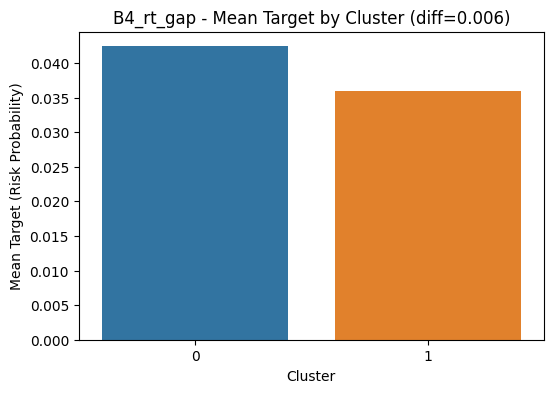

In [20]:
feature_list = ['B4_congruent_accuracy', 'B4_incongruent_accuracy',
                'B4_accuracy_gap', 'B4_mean_rt_congruent', 'B4_mean_rt_incongruent',
                'B4_rt_gap']
results_b4 = []

for col in feature_list:
    labels, sil_score, x_scaled, x_sample = compute_clusters_silhouette(train_b, col, y)
    diff = plot_cluster_target_mean(labels, x_sample, y, col)

    results_b4.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

    results.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

In [21]:
results_b4_df = pd.DataFrame(results_b4).sort_values('Cluster Diff', ascending=False)
results_b4_df

,Feature,Silhouette,Cluster Diff
3,B4_mean_rt_congruent,0.980533,0.042376
5,B4_rt_gap,0.968617,0.006418
4,B4_mean_rt_incongruent,0.981057,0.004187
1,B4_incongruent_accuracy,0.788702,0.003177
0,B4_congruent_accuracy,0.571478,0.001885
2,B4_accuracy_gap,0.564911,0.000796


## **B5**

Feature: B5_accuracy, Silhouette Score: 0.7344
Cluster별 Target 평균:
Cluster
0    0.039873
1    0.056348
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0165


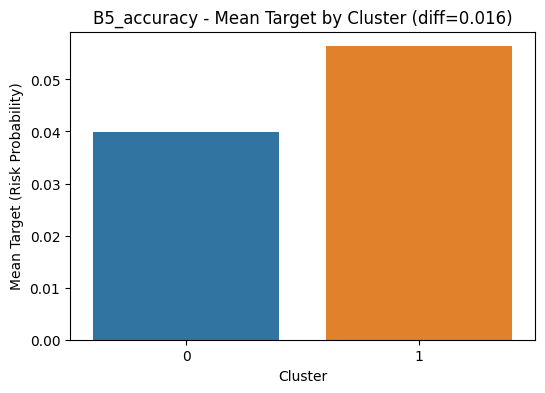

Feature: B5_mean_rt, Silhouette Score: 0.6020
Cluster별 Target 평균:
Cluster
0    0.042231
1    0.042451
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0002


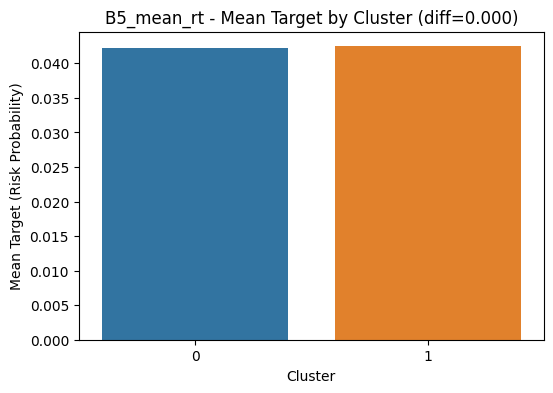

In [22]:
feature_list = ['B5_accuracy', 'B5_mean_rt']
results_b5 = []

for col in feature_list:
    labels, sil_score, x_scaled, x_sample = compute_clusters_silhouette(train_b, col, y)
    diff = plot_cluster_target_mean(labels, x_sample, y, col)

    results_b5.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

    results.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

In [23]:
results_b5_df = pd.DataFrame(results_b5).sort_values('Cluster Diff', ascending=False)
results_b5_df

,Feature,Silhouette,Cluster Diff
0,B5_accuracy,0.734391,0.016474
1,B5_mean_rt,0.602000,0.000220


## **B6, B7, B8**

Feature: B6_accuracy, Silhouette Score: 0.8264
Cluster별 Target 평균:
Cluster
0    0.042110
1    0.046798
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0047


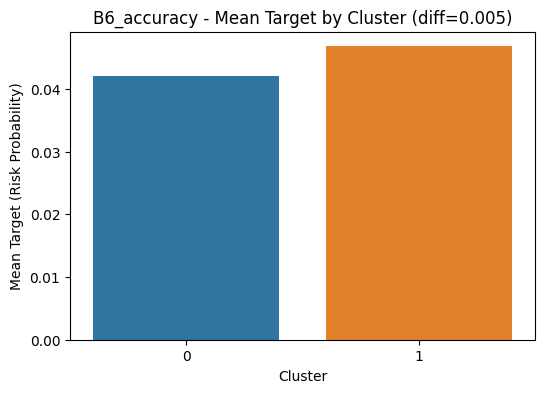

Feature: B7_accuracy, Silhouette Score: 0.6293
Cluster별 Target 평균:
Cluster
0    0.039890
1    0.046911
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0070


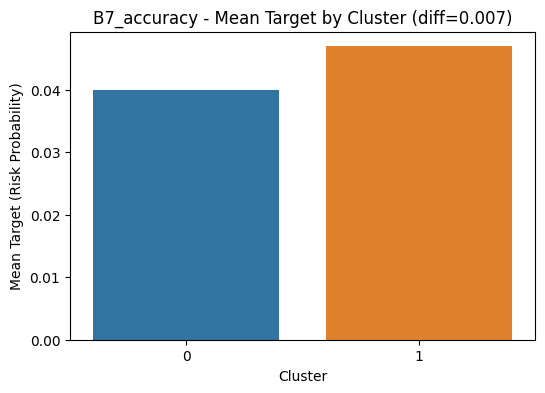

Feature: B8_accuracy, Silhouette Score: 0.9616
Cluster별 Target 평균:
Cluster
0    0.040742
1    0.051604
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0109


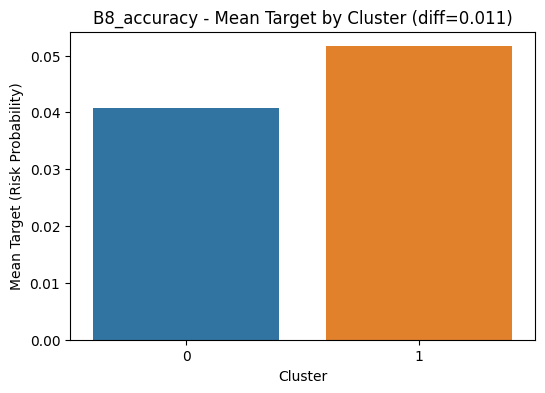

In [24]:
feature_list = ['B6_accuracy', 'B7_accuracy', 'B8_accuracy']
results_b678 = []

for col in feature_list:
    labels, sil_score, x_scaled, x_sample = compute_clusters_silhouette(train_b, col, y)
    diff = plot_cluster_target_mean(labels, x_sample, y, col)

    results_b678.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

    results.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

In [25]:
results_b678_df = pd.DataFrame(results_b678).sort_values('Cluster Diff', ascending=False)
results_b678_df

,Feature,Silhouette,Cluster Diff
2,B8_accuracy,0.961566,0.010861
1,B7_accuracy,0.629274,0.007021
0,B6_accuracy,0.826423,0.004688


## **B9**

Feature: B9_aud_hit, Silhouette Score: 0.9695
Cluster별 Target 평균:
Cluster
0    0.041509
1    0.052069
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0106


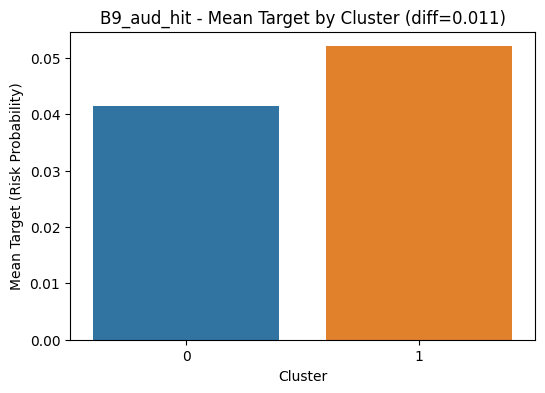

Feature: B9_aud_miss, Silhouette Score: 0.9695
Cluster별 Target 평균:
Cluster
0    0.041505
1    0.052139
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0106


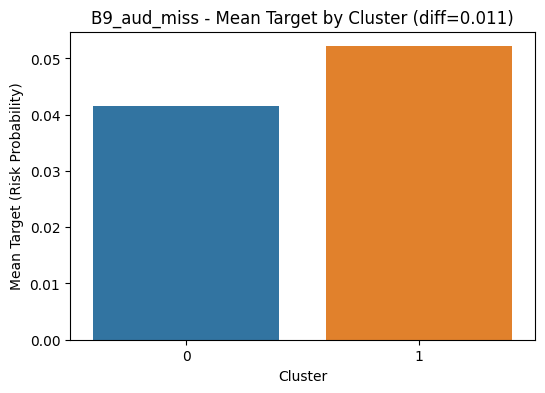

Feature: B9_aud_fa, Silhouette Score: 0.9249
Cluster별 Target 평균:
Cluster
0    0.041939
1    0.060000
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0181


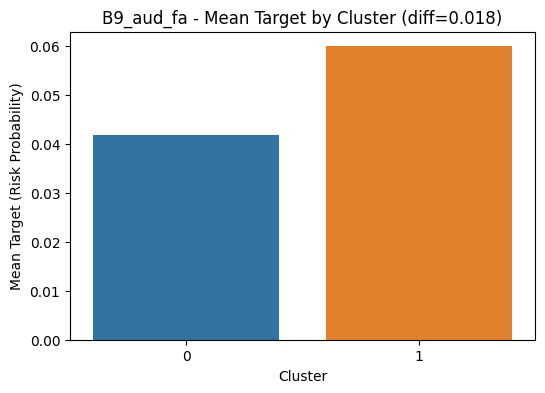

Feature: B9_aud_cr, Silhouette Score: 0.9252
Cluster별 Target 평균:
Cluster
0    0.041943
1    0.059701
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0178


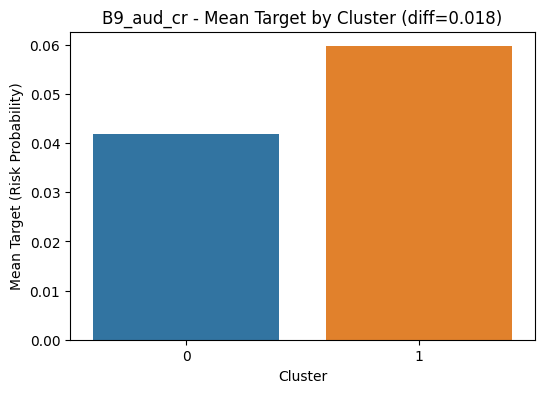

Feature: B9_vis_err, Silhouette Score: 0.7615
Cluster별 Target 평균:
Cluster
1    0.039630
0    0.042519
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0029


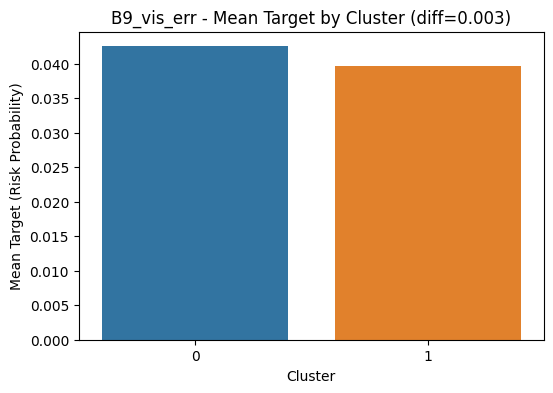

In [26]:
feature_list = ['B9_aud_hit', 'B9_aud_miss', 'B9_aud_fa', 'B9_aud_cr', 'B9_vis_err']
results_b9 = []

for col in feature_list:
    labels, sil_score, x_scaled, x_sample = compute_clusters_silhouette(train_b, col, y)
    diff = plot_cluster_target_mean(labels, x_sample, y, col)

    results_b9.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

    results.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

In [27]:
results_b9_df = pd.DataFrame(results_b9).sort_values('Cluster Diff', ascending=False)
results_b9_df

,Feature,Silhouette,Cluster Diff
2,B9_aud_fa,0.924947,0.018061
3,B9_aud_cr,0.925229,0.017758
1,B9_aud_miss,0.969455,0.010634
0,B9_aud_hit,0.969456,0.010560
4,B9_vis_err,0.761509,0.002889


## **B10**

Feature: B10_aud_hit, Silhouette Score: 0.8990
Cluster별 Target 평균:
Cluster
0    0.041984
1    0.045906
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0039


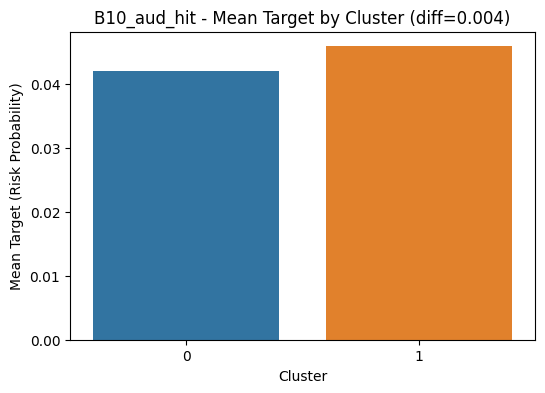

Feature: B10_aud_miss, Silhouette Score: 0.8990
Cluster별 Target 평균:
Cluster
0    0.041984
1    0.045906
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0039


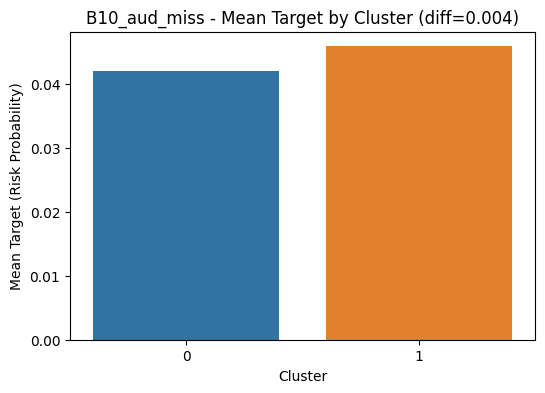

Feature: B10_aud_fa, Silhouette Score: 0.8939
Cluster별 Target 평균:
Cluster
0    0.042066
1    0.054945
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0129


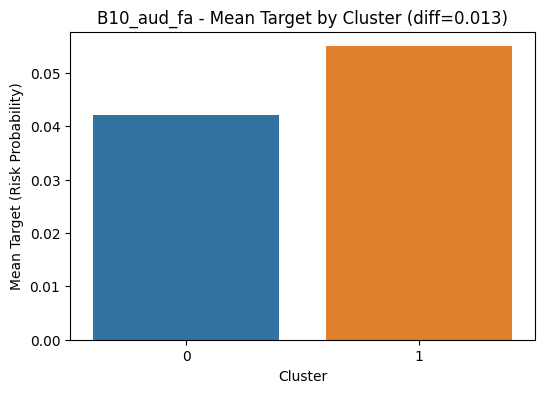

Feature: B10_aud_cr, Silhouette Score: 0.8939
Cluster별 Target 평균:
Cluster
0    0.042066
1    0.054945
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0129


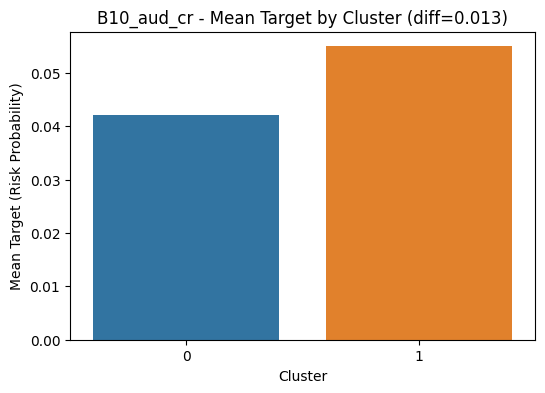

Feature: B10_vis1_err, Silhouette Score: 0.8653
Cluster별 Target 평균:
Cluster
1    0.040698
0    0.042328
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0016


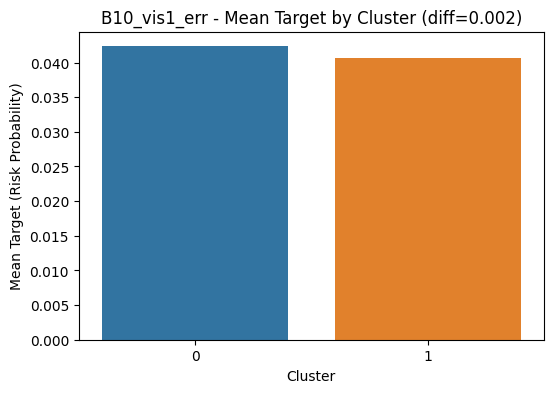

Feature: B10_vis2_correct, Silhouette Score: 0.9156
Cluster별 Target 평균:
Cluster
1    0.039007
0    0.042497
Name: Target, dtype: float64
Target 평균 차이 (Cluster Max - Min): 0.0035


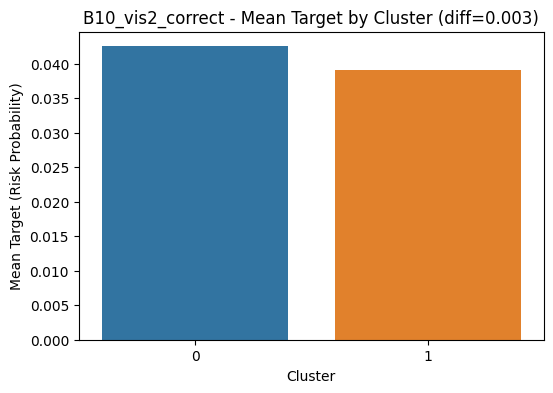

In [28]:
feature_list = ['B10_aud_hit', 'B10_aud_miss', 'B10_aud_fa',
                'B10_aud_cr', 'B10_vis1_err', 'B10_vis2_correct']
results_b10 = []

for col in feature_list:
    labels, sil_score, x_scaled, x_sample = compute_clusters_silhouette(train_b, col, y)
    diff = plot_cluster_target_mean(labels, x_sample, y, col)

    results_b10.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

    results.append({
        'Feature': col,
        'Silhouette': sil_score,
        'Cluster Diff': diff
    })

In [29]:
results_b10_df = pd.DataFrame(results_b10).sort_values('Cluster Diff', ascending=False)
results_b10_df

,Feature,Silhouette,Cluster Diff
3,B10_aud_cr,0.893904,0.012879
2,B10_aud_fa,0.893904,0.012879
1,B10_aud_miss,0.898968,0.003922
0,B10_aud_hit,0.898968,0.003922
5,B10_vis2_correct,0.915585,0.003490
4,B10_vis1_err,0.865318,0.001630


# **Result**

In [30]:
results_df = pd.DataFrame(results).sort_values('Cluster Diff', ascending=False)
results_df.head(20)

,Feature,Silhouette,Cluster Diff
16,B4_mean_rt_congruent,0.980533,0.042376
26,B9_aud_fa,0.924947,0.018061
27,B9_aud_cr,0.925229,0.017758
19,B5_accuracy,0.734391,0.016474
1,B1_task1_accuracy,0.794007,0.015074
31,B10_aud_fa,0.893904,0.012879
32,B10_aud_cr,0.893904,0.012879
23,B8_accuracy,0.961566,0.010861
25,B9_aud_miss,0.969455,0.010634
24,B9_aud_hit,0.969456,0.010560
